
# Universitat Oberta de Catalunya  
## Grado en Ingeniería Informática  
### Trabajo Final de Grado (TFG)

---

## Sistema de recomendaciones basado en técnicas de aprendizaje automático para ampliar la exploración de géneros musicales 
**Autor:** Marc Fernández Pereira  
**Bajo supervisión de:** Dra. María Moreno de Castro  
**Área:** Inteligencia Artificial  
**Semestre:** Otoño 2025  



---

## Índice



In [59]:
# Este import centraliza todas las librerías estándar, scikit-learn y funciones personalizadas
from imports import *

### Funciones

In [60]:
# Paleta fija con colores diferenciados (hasta 10 clústeres).
palette_colors = [
    '#1f77b4',  # azul
    '#ff7f0e',  # naranja
    '#2ca02c',  # verde
    '#d62728',  # rojo
    '#9467bd',  # morado
    '#8c564b',  # marrón
    '#17becf',  # cian
    '#7f7f7f',  # gris
    '#bcbd22',  # oliva
    '#000000'   # negro
]


def cluster_silhouette_score(model, X, sample_size=10000):
    """
    Calcula el coeficiente de Silhouette como métrica de validación interna para clustering.
    Adaptada para su uso con permutation_importance de scikit-learn.
    
    :param model: Modelo de clustering entrenado (KMeans, GMM, etc.)
    :param X: Matriz de características (n_samples, n_features)
    :param sample_size: Tamaño de muestra para reducir coste computacional (por defecto 10000)
    :return: Coeficiente de Silhouette (valores entre -1 y 1)
    """
    labels = model.predict(X)
    return silhouette_score(X, labels, sample_size=sample_size, random_state=42)



### Carga de datos y modelos entrenados en el cuaderno de clustering


In [61]:
# Cargar dataset preprocesado
df = pd.read_csv('spotify_tracks_clean.csv')

# Cargar scaler y PCA
scaler = joblib.load('scaler_object.pkl')
pca = joblib.load('models/pca_95var.pkl')

# Variables utilizadas en el modelado de clustering
selected_vars = ['energy', 'acousticness', 'danceability', 'valence', 'tempo', 'liveness']

# Matriz de características original
X = df[selected_vars].copy()

# Datos estandarizados (mismas variables que en el cuaderno de modelado)
df_scaled = pd.DataFrame(
    scaler.transform(X),
    columns=[f"{col}_norm" for col in selected_vars]
)

# Proyección PCA (mismas componentes que en el cuaderno de modelado)
X_pca = pca.transform(df_scaled)
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

# Cargar modelos de clustering
kmeans_k4_estand = joblib.load('models/kmeans_k4_estand.pkl')
kmeans_k7_estand = joblib.load('models/kmeans_k7_estand.pkl')
kmeans_k4_pca = joblib.load('models/kmeans_k4_pca.pkl')
kmeans_k7_pca = joblib.load('models/kmeans_k7_pca.pkl')
gmm_n20_pca = joblib.load('models/gmm_n20_pca.pkl')


# 4. eXplainable AI (XAI)

En el apartado “1.1.3 Una nueva oportunidad” se ha señalado que la IA Confiable constituye un concepto amplio y complejo cuyo propósito es definir un marco ético-social para el uso de la inteligencia artificial, con el fin de prevenir posibles daños a personas, ecosistemas u organizaciones, entre otros. Los tres pilares que fundamentan que una inteligencia artificial es confiable son la la legalidad, la ética y la robustez. Para alcanzar estos pilares un grupo de expertos de alto nivel sobre IA presentó el 8 de abril del 2019 una serie de directrices en el que se recogen los 7 requisitos presentados en la figura 3: agencia humana y supervisión, solidez técnica y seguridad, transparencia, diversidad, no discriminación y equidad, bienestar y responsabilidad [29][47].

En términos generales, la explicabilidad de la inteligencia artificial (Explainable AI), junto con la trazabilidad y la comunicación, constituye las tres dimensiones que definen la transparencia. Antes de explicar en que consiste la explicabilidad, conviene entender de manera clara qué significa la transparencia en este contexto. 
En el marco de la IA Confiable, la transparencia es la propiedad de un sistema inteligente que garantiza que las personas puedan acceder a la información  necesaria para comprender cómo se ha creado una inteligencia artificial y cómo toma sus decisiones. En la actualidad, existe hasta tres niveles distintos de transparencia:

- **Simulabilidad**: la capacidad de un ser humano de que pueda simular un modelo inteligente.
- **Descomponibilidad**: capacidad de poder entender cada parte del modelo independientemente.
- **Transparencia algorítmica**: la capacidad de comprender el funcionamiento del modelo y su manera de actuar frente a cualquier input.

Dado que la transparencia exige que las personas comprendan cómo se han desarrollado y cómo operan los sistemas de IA, la explicabilidad adquiere un papel fundamental en este proceso. En este sentido, la explicabilidad se entiende como la capacidad de un modelo para proporcionar una explicación clara y comprensible sobre que permita interpretar cómo y porqué toma determinadas decisiones o predicciones. 

Como se ha comentado en el apartado 1.1.3, en múltiples ocasiones los modelos inteligentes actúan como cajas negras, donde se introducen una serie de inputs que son procesados para generar outputs sin  que exista una comprensión explícita de los pasos intermedios ni de los factores que influyen en dichas decisiones. Este hecho puede convertirse en un problema, ya que no se puede predecir como actuará un modelo en situaciones inesperadas así ni cómo corregir si alguna cosa falla. 

En la actualidad, existen diferentes características para definir la taxonomía de la explicabilidad. A continuación, se presentan las más relevantes [48][49]:

En función del tipo de técnica:

- **Métodos agnosticos del modelo** (): técnicas que pueden aplicarse a cualquier tipo de algoritmo indepenedientemente de su complejidad o estructura interna. Los métodos más conocidos son LIME (*Local Interpretable Model Agnostic Explanation*) y SHAP(*Shapley Additive Exlanations*).
- **Métodos específicos del modelo** (): estas técnicas suelen estar integradas en el propio modelo de IA así que son métodos más específicos. Algunas técnicas populares son: los árboles de decisión o los modelos basados en reglas.

En función del comportamiento del modelo:

- ***ex-ante*** (*explainable-by-design*): algunos modelos como los lineales o los árboles de decisión tienen propiedades intrínsecas que facilitan su interpretación sin necesidad de generar modelos adicionales y añadir complejidad extra. Por ejemplo, los modelos lineales utilizan pesos que pueden explicar la importancia de cada característica. Por otro lado, los árboles pueden utilizar una característica a la hora de generar información mediante sus nodos para explicar dicha característica.
- ***post-hoc***: los modelos que no pueden explicar sus características de manera intrínseca, se consideran modelos post-hoc.


En función del alcance de la explicación:

- **Locales**: centradas en interpretar la predicción que realiza el modelo para una muestra o instancia concreta. 
- **Globales**: centradas en explicar el modelo de manera global.


En función del formato o naturaleza de la explicación generada. Existen multitud de técnicas que generan diferentes tipos de explicaciones.

A partir de esta clasificación, para el desarrollo de la explicabilidad se ha decidido seleccionar K-Means como modelo de referencia, ya que fue el algoritmo que ofreció los mejores resultados en la fase de modelado. El objetivo principal tratará de entender cómo y por qué k-means genera los diferentes clústeres y cómo asigna cada muestra a cada grupo.

Para abordar con esto, se decide implementar dos técnicas post-hoc agnósticas al modelo: Permutation Feature Importance (PFI) y Shapley Additive Explanation (SHAP), las cuales permiten analizar tanto la importancia global de las características como la contribución individual en la asignación de los clústeres.



## 4.1 Permutation Feature Importance (PFI)

La técnica Permutation Feature Importance se emplea en aprendizaje automático para evaluar la importancia de las características al medir cómo se altera el rendimiento del modelo cuando las características se permutan de manera aleatoria. Sin embargo, al tratarse de un problema no supervisado, este enfoque no puede aplicarse sobre predicciones. En su lugar, se utilizará PFI para analizar cómo cambian las métricas internas de calidad del modelo cuando se modifica la distribución de cada característica. Dicho de otro modo, en un proyecto de *clustering* la importancia de características se utiliza para visualizar que variables del conjunto de datos son más influyentes en la definición y formación de clústeres [46].

La extracción de la importancia de características otorga múltiples beneficios al proyecto:

- Aumento de la interpretabilidad: el hecho de detectar que características son más influyentes a la hora de generar las agrupaciones permite incrementar la interpretabilidad del modelo.
- Reducción de dimensionalidad: al igual que en el punto anterior, conocer qué características son más influyentes permite reducir la dimensionalidad del conjunto de datos descartando aquellas que no aportan información relevante a la formación de los clústeres. Además, esta reducción de dimensionalidad contribuye a mejorar el rendimiento del modelo desde el punto de vista del coste computacional. 
- Ingeniería de características: conocer la importancia de las características facilita la identificación de patrones relevantes y puede orientar la creación de nuevas características que capturen mejor la información del conjunto de datos.
- Mejora del rendimiento al agrupar observaciones: mediante la importancia de características se pueden detectar las menos influyentes para descartarlas del conjunto de datos y así contribuir a que los algoritmos de agrupación produzcan clústeres más significativos y precisos.

Como se ha comentado anteriormente, el uso de PFI en modelos no supervisados adopta un enfoque distintos frente a los algoritmos supervisados. Para comprender como debe funcionar PFI en este contexto se exponen los pasos que seguirá el algoritmo [46]:

- Se define una la función de agrupación, en este caso los modelos k-means entrenados en la fase de modelado.
- Se define una métrica de calidad de agrupación, en este caso se escoge el índice de la silueta. Esta métrica servirá para evaluar el rendimiento del modelo a la hora de permutar las diferentes características.
- El algoritmo, internamente permuta n veces los valores de una característica seleccionada arbitráriamente.
- Se vuelve a realizar el primer y el segundo paso después de permutar los valores de una característica.
- El algoritmo compara las métricas de calidad antes y después de permutar para determinar la importancia de la característica.

Así pues, se procede a implementar el método agnóstico pos-hoc Permutation Feature Importance:

### 4.1.1 Función de scoring personalizada para Permutation Feature Importance

Para poder extraer la importancia de las características permutando múltiples veces las variables del conjunto de datos, se debe establecer una función (scoring) que permita evaluar el modelo. Sin embargo, existe una diferencia fundamental en cómo funciona el algoritmo en aprendizaje supervisado y no supervisado. 

En el contexto del aprendizaje supervisado, el algoritmo PFI utiliza el parámetro $y$ para identificar las etiquetas reales del conjunto de datos. De esta manera, el algoritmo puede evaluar el rendimiento de un modelo supervisado en base a métricas como f1 Score, Accuracy Score, o r2 Score entre otros.  Sin embargo, para su uso bajo un contexto de aprendizaje no supervisado donde no se dispone de etiquetas reales, resulta indispensable declarar una función de scoring personalizada que ayude a medir el rendimiento de un modelo de *clustering* mediante una métrica como SH, elbow method o CH.

Para este propósito, se ha implementado la función **cluster_silhouette_score**, que adapta el cálculo del coeficiente de Silhouette para su uso con **permutation_importance**. Para comprobar que es correcta, se procede a visualizar los valores de silueta de los modelos desarrollados en el apartado de modelado:

In [62]:
# Cálculo del coeficiente de Silhouette para los modelos K-Means
# K-Means k=4 con PCA
sil_k4_pca = cluster_silhouette_score(kmeans_k4_pca, X_pca_df)

# K-Means k=7 con PCA
sil_k7_pca = cluster_silhouette_score(kmeans_k7_pca, X_pca)

# K-Means k=7 sin PCA (sobre datos estandarizados)
sil_k7_estand = cluster_silhouette_score(kmeans_k7_estand, df_scaled)

# K-Means k=4 sin PCA (sobre datos estandarizados)
sil_k4_estand = cluster_silhouette_score(kmeans_k4_estand, df_scaled)

print(f"Silhouette K-Means k=4 (PCA): {sil_k4_pca:.2f}")
print(f"Silhouette K-Means k=7 (PCA): {sil_k7_pca:.2f}")
print(f"Silhouette K-Means k=4 (Sin PCA): {sil_k4_estand:.2f}")
print(f"Silhouette K-Means k=7 (Sin PCA): {sil_k7_estand:.2f}")

Silhouette K-Means k=4 (PCA): 0.25
Silhouette K-Means k=7 (PCA): 0.20
Silhouette K-Means k=4 (Sin PCA): 0.24
Silhouette K-Means k=7 (Sin PCA): 0.18


### 4.1.2 Cálculo de la importancia de variables para K-Means k=4 sobre PCA

El primer paso que se ha realizado es la visualización de los resultados de PFI sobre el modelo K-Means con $k=4$ sobre PCA ya que, según las métricas de calidad extraídas en la fase de modelado, es el mejor modelo en términos de rendimiento. 


In [81]:
# Tomamos una muestra representativa del conjunto de datos para acelerar el proceso ya que computacionalmente es muy costosa
X_pca_sample = X_pca_df.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=4 (sobre muestra PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k4_pca.pkl'):
    p_importance_k4_pca = joblib.load('resultados_explicabilidad/p_importance_k4_pca.pkl')
else:
    p_importance_k4_pca = permutation_importance(
        kmeans_k4_pca,
        X_pca_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

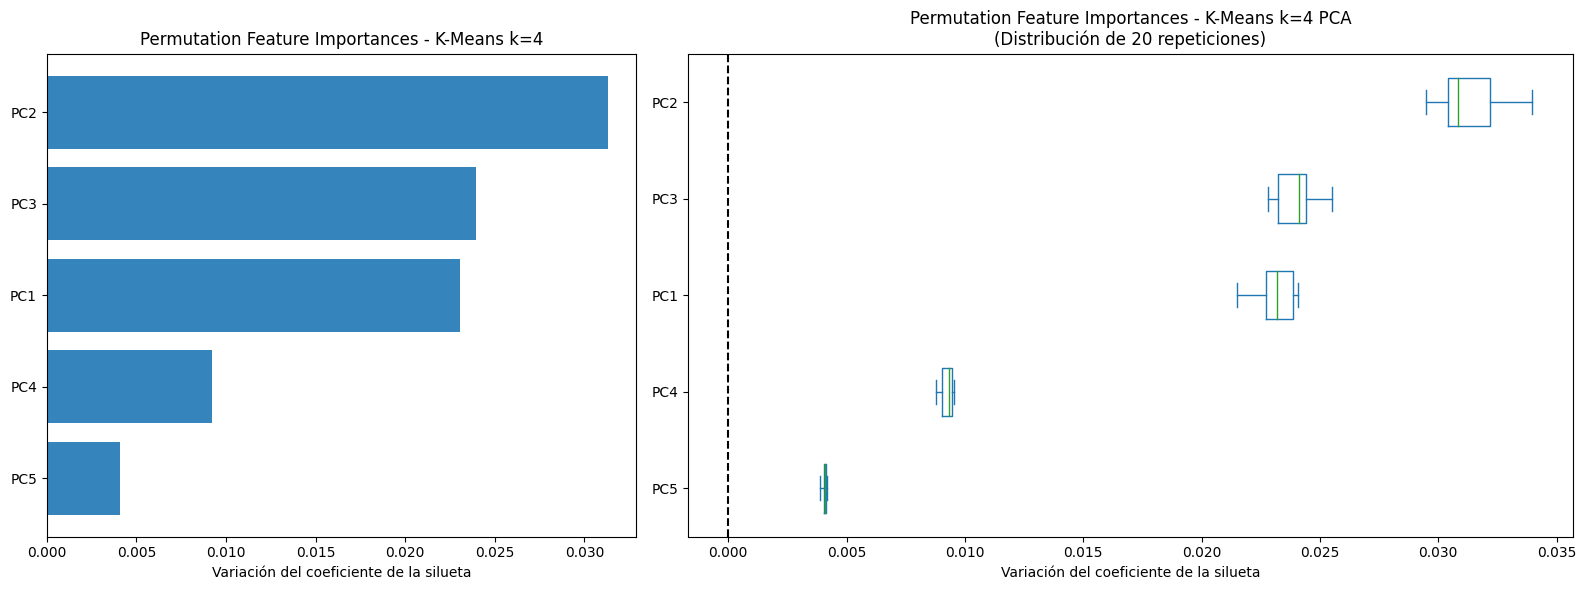

In [83]:
# Extraemos nombres de las features (componentes principales en este caso)
feature_names = X_pca_sample.columns.values

# Ordenación en función de la importancia
sorted_indices_perm = np.argsort(np.abs(p_importance_k4_pca.importances_mean))

# Crear figura con dos subplots con proporciones 40% y 60%
fig, axs = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[4, 6])

# Gráfico de barras para mostrar resultados
axs[0].barh(range(len(feature_names)), p_importance_k4_pca.importances_mean[sorted_indices_perm], alpha=0.9)
axs[0].set_yticks(range(len(feature_names)))
axs[0].set_yticklabels(feature_names[sorted_indices_perm])
axs[0].set_title("Permutation Feature Importances - K-Means k=4")
axs[0].set_xlabel("Variación del coeficiente de la silueta")

# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx = p_importance_k4_pca.importances_mean.argsort()
# Generamos un nuevo df cib todas las repeticiones
importances = pd.DataFrame(
    p_importance_k4_pca.importances[sorted_importances_idx].T,
    columns=feature_names[sorted_importances_idx],
)
# Construimos boxplot de la distribución de importancias de cada variable
importances.plot.box(vert=False, whis=10, ax=axs[1])
axs[1].set_title("Permutation Feature Importances - K-Means k=4 PCA\n(Distribución de 20 repeticiones)")
axs[1].axvline(x=0, color="k", linestyle="--")
axs[1].set_xlabel("Variación del coeficiente de la silueta")

plt.tight_layout()
plt.show()

Para interpretar los resultados, se ha considerado que aquella característica (feature) que presente la variación más elevada sobre el coeficiente de *Silhouette* al ser permutada será la más influyente en la formación de los clústeres. En este caso, se ha observado que la característica que más influye es PC2 consiguiendo variar el valor de la silueta en 20 repeticiones del algoritmo un 0.032 aproximadamente. Seguidamente, PC3 y PC2 consiguen variar aproximadamente un 0.020. Por último, las características menos influyentes, es decir, las más próximas a 0 son PC4 y PC5.

Estos resultados han puesto en evidencia que la característica más importante para el modelo K-Means $k=4$ sobre PCA es PC2 que corresponde mayormente, según la calidad de representación (cos2) extraída en el apartado de PCA, a las variables danceability y valence. Esto quiere decir, que la *bailabilidad* y la positividad emocional de una canción son las características que más influyen a la hora de generar los clústeres por parte del algoritmo. Por otro lado, PC3 (mayormente liveness con un 70% de representación) es la siguiente característica que influye en la formación de clústeres junto a PC1 ( representada mayormente por *accousticness* y *energy*). Por último, las características menos importantes en la generación de clústeres PC4 y PC5 corresponden mayormente a la variable tempo. Este hecho ha sugerido que el tempo no es un factor que influya en gran medida a la asignación de los *tracks* a cada clúster. 

### 4.1.3 Cálculo de la importancia de variables para K-Means k=7 sobre PCA

Después de analizar la importancia de las características al permutar las variables de K-Means $k=4$ sobre PCA se ha procedido a realizar el mismo estudio para el modelo K-Means $k=7$ seleccionado como modelo candidato para el sistema de recomendación musical.



In [66]:
# Permutation Feature Importance para K-Means k=7 (sobre muestra PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k7_pca.pkl'):
    p_importance_k7_pca = joblib.load('resultados_explicabilidad/p_importance_k7_pca.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k7_pca = permutation_importance(
        kmeans_k7_pca,
        X_pca_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

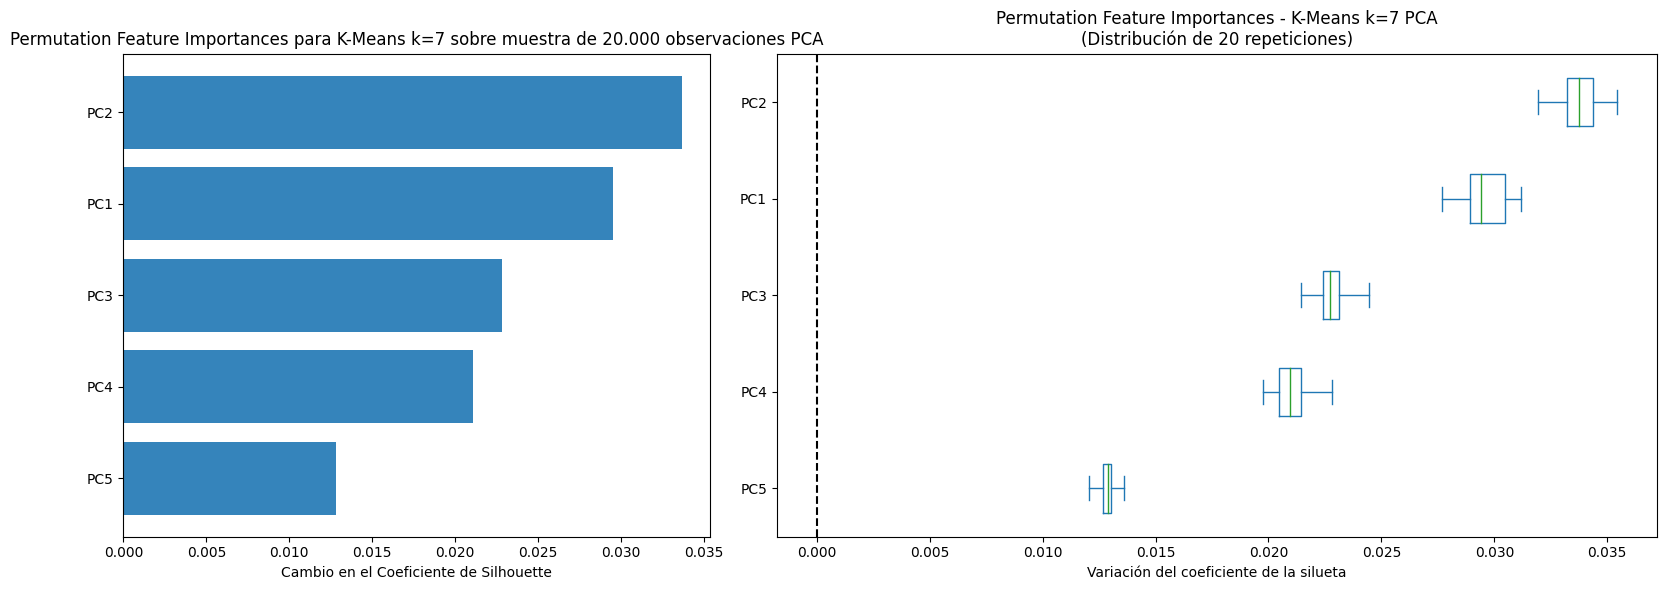

In [89]:
# Nombres de las features (componentes principales)
feature_names_k7 = X_pca_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_k7 = np.argsort(np.abs(p_importance_k7_pca.importances_mean))

# Crear figura con dos subplots con proporciones 40% y 60%
fig, axs = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[4, 6])

# Visualizamos con los atributos ordenados de menor a mayor importancia
axs[0].barh(range(len(feature_names_k7)), p_importance_k7_pca.importances_mean[sorted_indices_perm_k7], alpha=0.9)
axs[0].set_yticks(range(len(feature_names_k7)))
axs[0].set_yticklabels(feature_names_k7[sorted_indices_perm_k7])
axs[0].set_title("Permutation Feature Importances para K-Means k=7 sobre muestra de 20.000 observaciones PCA")
axs[0].set_xlabel("Cambio en el Coeficiente de Silhouette")

# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_k7 = p_importance_k7_pca.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_k7 = pd.DataFrame(
    p_importance_k7_pca.importances[sorted_importances_idx_k7].T,
    columns=feature_names_k7[sorted_importances_idx_k7],
)
# Construimos el boxplot de la distribución de importancias de cada componente principal
importances_k7.plot.box(vert=False, whis=10, ax=axs[1])
axs[1].set_title("Permutation Feature Importances - K-Means k=7 PCA\n(Distribución de 20 repeticiones)")
axs[1].axvline(x=0, color="k", linestyle="--")
axs[1].set_xlabel("Variación del coeficiente de la silueta")

plt.tight_layout()
plt.show()

En términos generales se ha observado que la media de importancia de las variables identificadas como "menos importantes" para $k=4$ han aumentado casi el doble. Además, la segunda característica más importante en esta ocasión es PC2 que consigue una media de importancia cercana al 0.030. Este último hecho se ha considerado muy importante ya que demuestra que la formación de clústeres está más influenciada por la permutación de accousticness y energy (PC1) que por liveness (PC3). Sin embargo, estos resultados demuestran que a pesar de que hay características que influyen más que otras, todas tienen una mínima influencia e la hora de agrupar las canciones en distintos clústeres. 

### 4.1.4 Cálculo de la importancia de variables para K-Means k=4 sobre el conjunto estandarizado

In [69]:
# Muestra representativa para acelerar el cálculo
df_scaled_sample = df_scaled.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=4 sobre datos estandarizados (sin PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k4_estand.pkl'):
    p_importance_k4_estand = joblib.load('resultados_explicabilidad/p_importance_k4_estand.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k4_estand = permutation_importance(
        kmeans_k4_estand,
        df_scaled_sample,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )


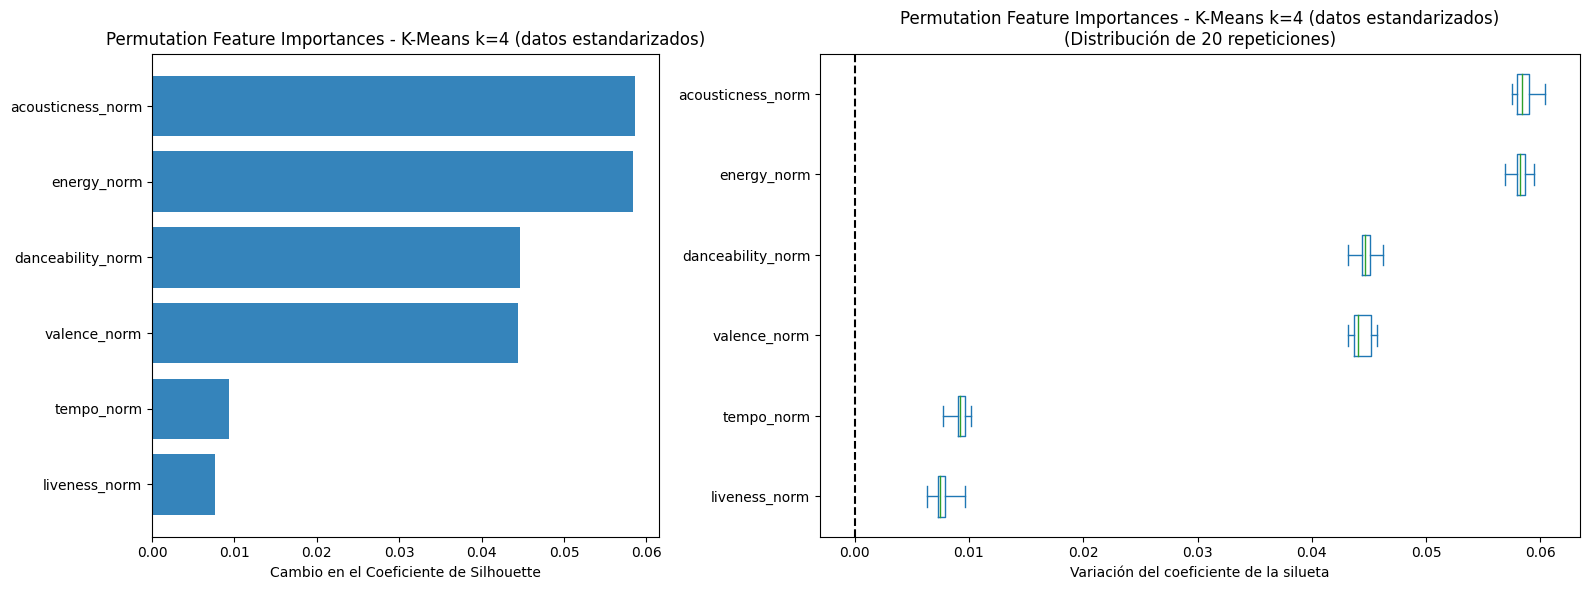

In [86]:
# Nombres de las features (variables estandarizadas)
feature_names_k4_estand = df_scaled_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_k4_estand = np.argsort(np.abs(p_importance_k4_estand.importances_mean))

# Crear figura con dos subplots con proporciones 40% y 60%
fig, axs = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[4, 6])

# Visualizamos con los atributos ordenados de menor a mayor importancia
axs[0].barh(range(len(feature_names_k4_estand)), p_importance_k4_estand.importances_mean[sorted_indices_perm_k4_estand], alpha=0.9)
axs[0].set_yticks(range(len(feature_names_k4_estand)))
axs[0].set_yticklabels(feature_names_k4_estand[sorted_indices_perm_k4_estand])
axs[0].set_title("Permutation Feature Importances - K-Means k=4 (datos estandarizados)")
axs[0].set_xlabel("Cambio en el Coeficiente de Silhouette")

# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_k4_estand = p_importance_k4_estand.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_k4_estand = pd.DataFrame(
    p_importance_k4_estand.importances[sorted_importances_idx_k4_estand].T,
    columns=feature_names_k4_estand[sorted_importances_idx_k4_estand],
)
# Construimos el boxplot de la distribución de importancias de cada variable estandarizada
importances_k4_estand.plot.box(vert=False, whis=10, ax=axs[1])
axs[1].set_title("Permutation Feature Importances - K-Means k=4 (datos estandarizados)\n(Distribución de 20 repeticiones)")
axs[1].axvline(x=0, color="k", linestyle="--")
axs[1].set_xlabel("Variación del coeficiente de la silueta")

plt.tight_layout()
plt.show()


### 4.1.5 Cálculo de la importancia de variables para K-Means k=7 sobre el conjunto estandarizado

In [72]:
# Muestra representativa para acelerar el cálculo
df_scaled_sample = df_scaled.sample(n=20000, random_state=42)

# Permutation Feature Importance para K-Means k=7 sobre datos estandarizados (sin PCA)
# Si existe el resultado guardado, lo cargamos; si no, lo calculamos
import os
if os.path.exists('resultados_explicabilidad/p_importance_k7_estand.pkl'):
    p_importance_k7_estand = joblib.load('resultados_explicabilidad/p_importance_k7_estand.pkl')
else:
    # Convertimos a array numpy para evitar warnings (el modelo fue entrenado sin feature names)
    p_importance_k7_estand = permutation_importance(
        kmeans_k7_estand,
        df_scaled_sample.values,
        y=None,
        n_repeats=20,
        random_state=42,
        scoring=cluster_silhouette_score
    )

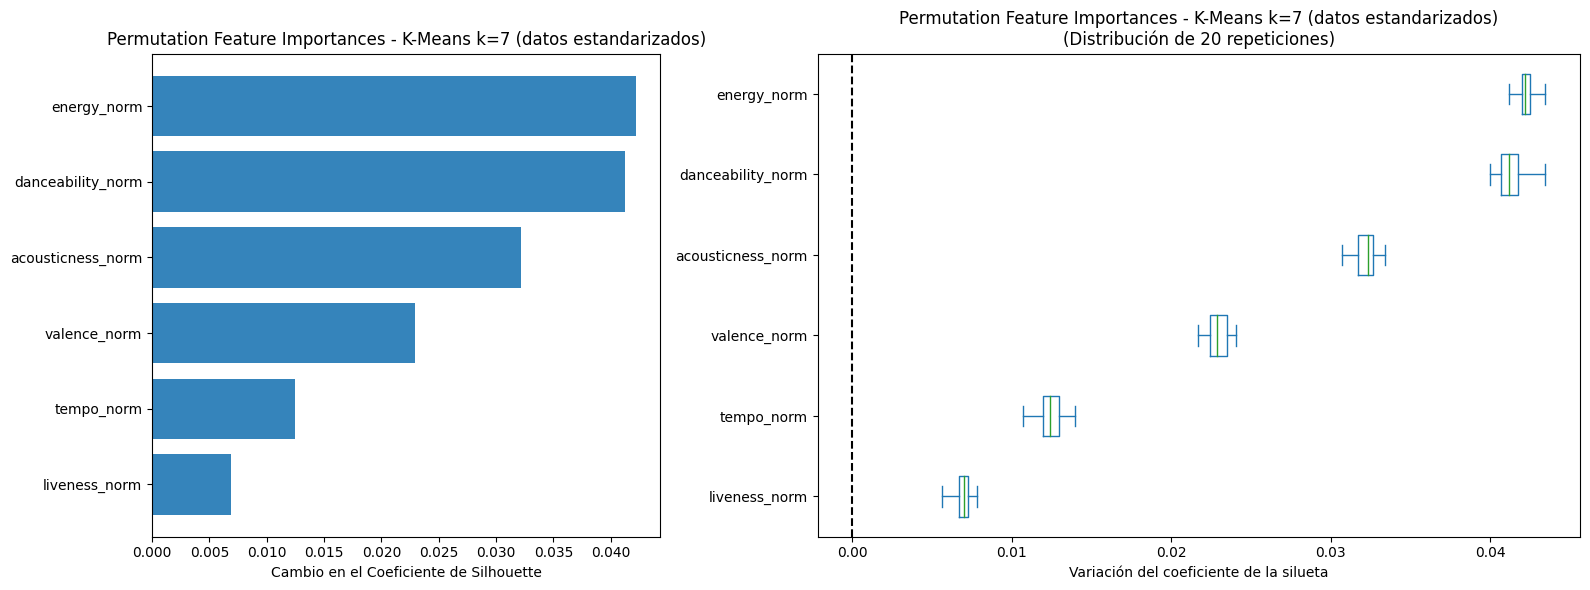

In [88]:
# Nombres de las features (variables estandarizadas)
feature_names_estand = df_scaled_sample.columns.values

# Ordenación de menor a mayor importancia (la menos importante arriba, la más importante abajo)
sorted_indices_perm_estand = np.argsort(np.abs(p_importance_k7_estand.importances_mean))

# Crear figura con dos subplots con proporciones 40% y 60%
fig, axs = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[4, 6])

# Visualizamos con los atributos ordenados de menor a mayor importancia
axs[0].barh(range(len(feature_names_estand)), p_importance_k7_estand.importances_mean[sorted_indices_perm_estand], alpha=0.9)
axs[0].set_yticks(range(len(feature_names_estand)))
axs[0].set_yticklabels(feature_names_estand[sorted_indices_perm_estand])
axs[0].set_title("Permutation Feature Importances - K-Means k=7 (datos estandarizados)")
axs[0].set_xlabel("Cambio en el Coeficiente de Silhouette")

# Boxplot de las importancias de permutación (muestra la distribución de las 20 repeticiones)
# Ordenamos variables en función de su importancia media
sorted_importances_idx_estand = p_importance_k7_estand.importances_mean.argsort()
# Generamos un nuevo DataFrame con todas las repeticiones
importances_estand = pd.DataFrame(
    p_importance_k7_estand.importances[sorted_importances_idx_estand].T,
    columns=feature_names_estand[sorted_importances_idx_estand],
)
# Construimos el boxplot de la distribución de importancias de cada variable estandarizada
importances_estand.plot.box(vert=False, whis=10, ax=axs[1])
axs[1].set_title("Permutation Feature Importances - K-Means k=7 (datos estandarizados)\n(Distribución de 20 repeticiones)")
axs[1].axvline(x=0, color="k", linestyle="--")
axs[1].set_xlabel("Variación del coeficiente de la silueta")

plt.tight_layout()
plt.show()

In [75]:
# Guardado de resultados de Permutation Feature Importance
import os
os.makedirs('resultados_explicabilidad', exist_ok=True)

# Guardar solo los resultados de Permutation Feature Importance
joblib.dump(p_importance_k4_pca, 'resultados_explicabilidad/p_importance_k4_pca.pkl')
joblib.dump(p_importance_k7_pca, 'resultados_explicabilidad/p_importance_k7_pca.pkl')
joblib.dump(p_importance_k4_estand, 'resultados_explicabilidad/p_importance_k4_estand.pkl')
joblib.dump(p_importance_k7_estand, 'resultados_explicabilidad/p_importance_k7_estand.pkl')

print("Resultados de Permutation Feature Importance guardados correctamente")

Resultados de Permutation Feature Importance guardados correctamente


### 4.1.5 Comparación e interpretación de la importancia de variables

TODO AQUI EXPLICACION

## 4.2 SHAP Values para clustering

### Definición de la función de salida para K-Means (distancias a centroides)

### Cálculo de SHAP Values para K-Means k=4

### Cálculo de SHAP Values para GMM n=20

### Visualización e interpretación de SHAP por clúster


In [76]:
# SHAP Values para K-Means k=4 sobre el espacio PCA

# Seleccionamos una muestra de fondo (background) para el KernelExplainer
# Esta muestra representa la distribución global y reduce el coste computacional
X_pca_background = X_pca_df.sample(n=20000, random_state=42)

# Seleccionamos un subconjunto de observaciones que queremos explicar
X_pca_explain = X_pca_df.sample(n=5000, random_state=24)

# Definimos el explicador SHAP usando la función predict de K-Means k=4
explainer_k4 = shap.KernelExplainer(
    model=kmeans_k4_pca.predict,
    data=X_pca_background.values,
)

# Calculamos los valores SHAP para las observaciones seleccionadas
shap_values_k4 = explainer_k4.shap_values(X_pca_explain.values)

# Visualización: summary plot en el espacio de componentes principales
shap.initjs()
shap.summary_plot(
    shap_values_k4,
    X_pca_explain,
    feature_names=X_pca_explain.columns
)


In [77]:
import shap
import numpy as np
from sklearn.metrics import pairwise_distances

if False:
    # 1) Background resumido con k-means de SHAP para ir más rápido
    X_pca_background = shap.kmeans(X_pca_df, 50)   # 50 puntos resumen

    # 2) Subconjunto de observaciones a explicar
    X_pca_explain = X_pca_df.sample(n=1000, random_state=24)

    # 3) Definimos una función "modelo" continua:
    #    devuelve -distancia euclídea a cada centroide (afinidad al clúster)
    def kmeans_affinity(X):
        """
        X: array (n_muestras, n_features)
        return: array (n_muestras, n_clusters)
                cada columna es la afinidad (-distancia) a un clúster
        """
        # distancias a cada centroide (n_muestras, n_clusters)
        D = pairwise_distances(X, kmeans_k4_pca.cluster_centers_, metric="euclidean")
        # afinidad = -distancia (cuanto más alto, más cerca del centroide)
        return -D

    # 4) Explicador SHAP sobre la función de afinidad a los clústeres
    explainer_k4 = shap.KernelExplainer(
        model=kmeans_affinity,
        data=X_pca_background
    )

    # 5) Cálculo de valores SHAP para las observaciones seleccionadas
    #    Esto devuelve una lista de arrays: uno por cada clúster (salida del modelo)
    shap_values_k4 = explainer_k4.shap_values(X_pca_explain.values)

    # 6) Summary plot para todas las salidas (clústeres) a la vez
    shap.initjs()
    shap.summary_plot(
        shap_values_k4,
        X_pca_explain,
        feature_names=X_pca_explain.columns
    )

    plt.tight_layout()

    plt.show()